<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 148.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 182.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 151.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 134.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [5]:
## Write your code here
df.describe(include=['object'])

/tmp/ipykernel_301/2034467434.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])

,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,SurveyLength,SurveyEase
count,65447,65447,65447,54812,65447,54472,60794,60498,49245,40902,...,27710,28911,28844,28251,27764,28491,28807,28858,56190,56246
unique,5,8,110,3,1,118,8,418,10853,113,...,5,5,5,954,514,3,9,15,3,3
top,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,...,1-2 times a week,30-60 minutes a day,15-30 minutes a day,None of these,None of these,Hybrid (on-prem and cloud),Traditional public search engine,Software Development,Appropriate in length,Easy
freq,50212,23911,39046,23015,65447,9995,24943,3676,603,6948,...,14426,10951,9341,2364,2834,13230,15813,11918,38771,30076


In [6]:
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65447.000000,3.374000e+04,29659.000000,29325.000000,29394.000000,29412.000000,29451.000000,29449.000000,29457.000000,29457.000000,29451.000000,29446.000000,2.343500e+04,29126.000000
mean,32714.001528,2.963841e+145,11.467143,18.580460,7.521884,10.060515,24.342405,22.964440,20.277477,16.168883,10.955341,9.953610,8.615529e+04,6.935041
std,18893.063225,5.444117e+147,9.168610,25.966005,18.422399,21.833543,27.089272,27.017612,26.107934,24.844789,22.905963,21.775359,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16352.500000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32714.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.000000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49075.500000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.000000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [7]:
## Write your code here
df.isnull().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64

##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



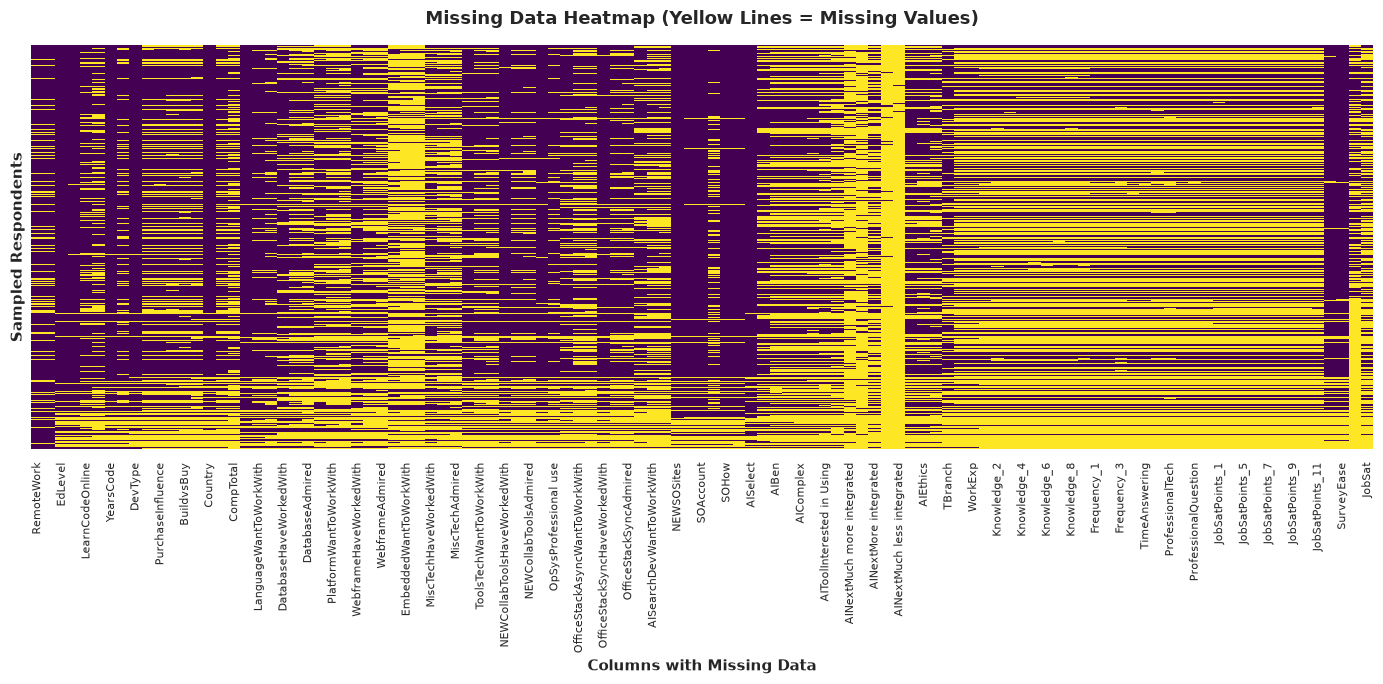

In [14]:
sns.set_theme(style="white")

# Filter to columns that have at least 1 missing value
missing_cols = df.columns[df.isnull().any()]
df_missing_subset = df[missing_cols]

plt.figure(figsize=(14, 7))

# Create heat map: df.isnull() returns True (1) for missing, False (0) for present
sns.heatmap(
    df_missing_subset.isnull(),
    cbar=False,  # Hide color bar legend
    cmap="viridis",  # Yellow/bright lines represent missing values (NaNs)
    yticklabels=False,  # Hide individual row indices for clarity
)

plt.title(
    "Missing Data Heatmap (Yellow Lines = Missing Values)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Columns with Missing Data", fontsize=11, fontweight="bold")
plt.ylabel("Sampled Respondents", fontsize=11, fontweight="bold")
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

 **Heatmap Observations:**
 Missing values are concentrated in specific clusters of columns rather than being completely randomly distributed. 


##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [19]:
# Specify the target column
target_col = "Employment"

# 1. Count missing values
missing_count = df[target_col].isnull().sum()

# 2. Calculate percentage
missing_pct = (missing_count / len(df)) * 100

# 3. Print formatted results
print(f"--- Missing Value Audit for '{target_col}' ---")
print(f"Missing Rows: {missing_count:,}")
print(f"Missing Percentage: {missing_pct:.2f}%")
print(f"Total Rows Checked: {len(df):,}")

--- Missing Value Audit for 'Employment' ---
Missing Rows: 0
Missing Percentage: 0.00%
Total Rows Checked: 65,447

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [20]:
## Write your code here
df[target_col].mode()

0    Employed, full-time
Name: Employment, dtype: str

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [23]:
## Write your code here
# Select target column with actual missing values
target_col = "EdLevel"

mode_val = df[target_col].mode()[0]
missing_before = df[target_col].isnull().sum()

print(f"--- Task 5: Imputing '{target_col}' ---")
print(f"Missing count before: {missing_before:,}")
print(f"Mode value to impute: '{mode_val}'")

# Perform imputation
df[target_col] = df[target_col].fillna(mode_val)

# Verify imputation
missing_after = df[target_col].isnull().sum()
print(f"Missing count after: {missing_after}")
print(f"Column '{target_col}' completeness: 100%")

--- Task 5: Imputing 'EdLevel' ---
Missing count before: 4,653
Mode value to impute: 'Bachelor’s degree (B.A., B.S., B.Eng., etc.)'
Missing count after: 0
Column 'EdLevel' completeness: 100%

 **Note on Task 5 Execution:**  
 Audit of the `Employment` column revealed 0 missing entries (100% complete). For demonstration of categorical mode imputation logic, we chose `EdLevel` (which contained 7.11% missing entries). All missing records were successfully filled using the most frequent category without altering the underlying distribution.

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


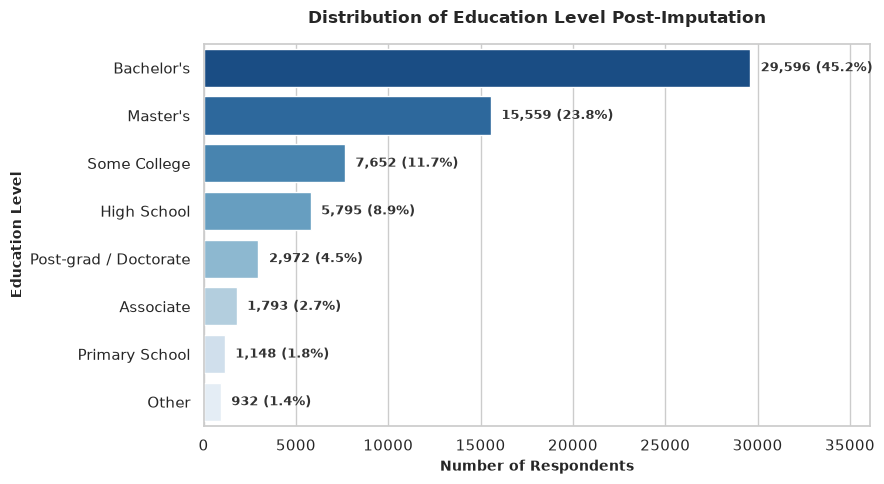

In [26]:
sns.set_theme(style="whitegrid")

# Dictionary to shorten long category labels
ed_label_map = {
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Bachelor's",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's",
    "Some college/university study without earning a degree": "Some College",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "High School",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Post-grad / Doctorate",
    "Associate degree (A.A., A.S., etc.)": "Associate",
    "Primary/elementary school": "Primary School",
    "Something else": "Other",
}

# Map shortened labels to a temporary plotting series
ed_series = df["EdLevel"].map(ed_label_map).fillna(df["EdLevel"])

# Calculate value counts and percentages
ed_counts = ed_series.value_counts().reset_index()
ed_counts.columns = ["Education_Level", "Count"]

plt.figure(figsize=(9, 5))

# Plot with concise labels
ax = sns.barplot(
    data=ed_counts,
    x="Count",
    y="Education_Level",
    palette="Blues_r",
    hue="Education_Level",
    legend=False,
)

# Add exact count and percentage annotations
total_rows = len(df)
for p in ax.patches:
    width = p.get_width()
    pct = (width / total_rows) * 100
    ax.annotate(
        f" {width:,.0f} ({pct:.1f}%)",
        (width + 300, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        fontsize=9,
        color="#333333",
        fontweight="bold",
    )

plt.title(
    "Distribution of Education Level Post-Imputation",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Respondents", fontsize=10, fontweight="bold")
plt.ylabel("Education Level", fontsize=10, fontweight="bold")
plt.xlim(0, max(ed_counts["Count"]) * 1.22)  # Space for labels

plt.tight_layout()
plt.show()

 **Post-Imputation Distribution Insights (`EdLevel`):**
 1. **Dominant Category Preserved:** "Bachelor’s degree (B.A., B.S., B.Eng., etc.)" remains the clear modal category, accounting for the largest share of overall responses.
 2. **Negligible Distribution Shift:** Because mode imputation was restricted to a low-missingness column (~7.11% missing), filling the missing entries reinforced the primary category without artificially distorting the relative proportions of secondary tiers (e.g., Master's degree or Doctoral studies).
 3. **Completeness Achieved:** `EdLevel` is now 100% complete across all 65,437 rows in `df`.

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
